#  Phase 3: Classification — FD002

## Objective
This phase focuses on classifying engine degradation stages (Stage 0–4) for the FD002 dataset using machine learning models. FD002 has **six operational conditions and one fault mode**, making classification more complex and realistic. This multi-class classification approach helps identify health conditions early, enabling predictive maintenance interventions.

---

##  Step-by-Step Summary

### Step 0 – Environment Setup
- Defined project structure:
  - `figures/phase3`, `models`, `report`
- Set `random_state = 42` for reproducibility.
- Aesthetics configured using `seaborn` and `matplotlib`.

### Step 1 – Load Dataset
- Loaded cleaned, cluster-labeled dataset: `corrected_clustered_train_FD002.csv`
- Dataset contains `unit`, `time`, operational settings, 21 sensors, and the target `final_stage`.

### Step 2 – Feature & Target Selection
- Final sensors selected after variance analysis and visual inspection:
  - `sensor_1`, `sensor_12`
- Feature matrix `X` and target `y = final_stage` created.

### Step 3 – Stratified Train-Test Split (Engine-wise)
- Used engine `unit` IDs to split the dataset into **80% train** and **20% test**.
- Stratification performed based on the first degradation stage per engine to preserve class distribution.
- Prevents cycle-level data leakage.

---

##  Classifier Training and Evaluation

### Step 4 – Random Forest
- Params: `n_estimators=150`, `max_depth=12`, `class_weight='balanced'`
- Results:
  - CV Mean F1: **0.9667**
  - Test Accuracy: **0.98**
  - Test Weighted F1: **0.98**
- Saved to: `rf_classifier_fd002.pkl`
- Confusion matrix: `rf_fd002_confusion_matrix.png`

### Step 5 – Support Vector Machine (SVM)
- Params: RBF kernel, `C=1`, `gamma='scale'`, `class_weight='balanced'`
- Results:
  - CV Mean F1: **0.9671**
  - Test Accuracy: **0.97**
  - Test Weighted F1: **0.97**
- Saved to: `svm_classifier_fd002.pkl`
- Confusion matrix: `svm_confusion_matrix_fd002.png`

### Step 6 – Logistic Regression
- Params: `multi_class='multinomial'`, `solver='lbfgs'`, `class_weight='balanced'`
- Results:
  - CV Mean F1: **0.9671**
  - Test Accuracy: **0.97**
  - Test Weighted F1: **0.97**
- Saved to: `logreg_classifier_fd002.pkl`
- Confusion matrix: `confusion_matrix_logreg_fd002.png`

### Step 7 – XGBoost
- Label encoding applied using `LabelEncoder`
- Params: `n_estimators=100`, `max_depth=6`, `learning_rate=0.1`
- Results:
  - CV Mean F1: **0.9776**
  - Test Accuracy: **0.98**
  - Test Weighted F1: **0.98**
- Saved to: `xgb_classifier_fd002.pkl`
- Confusion matrix: `confusion_matrix_xgb_fd002.png`

---

##  Step 8 – Model Comparison Summary

The following table summarizes cross-validation and test performance of all models:

| Model               | CV Mean F1 | Test Accuracy | Test Weighted F1 |
|--------------------|------------|----------------|------------------|
| Random Forest       | 0.9667     | 0.98           | 0.98             |
| SVM                 | 0.9671     | 0.97           | 0.97             |
| Logistic Regression | 0.9671     | 0.97           | 0.97             |
| XGBoost             | 0.9776     | 0.98           | 0.98             |

- Summary saved to: `model_comparison_fd002.csv`
- Bar plot saved to: `fd002_model_comparison_barplot.png`

---

# Step 0: Setup — Phase 3 FD002

In [1]:
# Step 0: Setup — Phase 3 FD002 (Inside notebooks/phase3)

import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Manual config — since we're inside notebooks/phase3, go two levels up
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
FIGURES_DIR = os.path.join(BASE_DIR, 'figures', 'phase3')
MODELS_DIR = os.path.join(BASE_DIR, 'models')
REPORT_DIR = os.path.join(BASE_DIR, 'report')
RANDOM_STATE = 42  # Global seed

# Plotting aesthetics
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14

# Set seed
np.random.seed(RANDOM_STATE)

# Create folders
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(REPORT_DIR, exist_ok=True)

# Confirm
print(f" Figures directory: {FIGURES_DIR}")
print(f" Models directory: {MODELS_DIR}")
print(f" Reports directory: {REPORT_DIR}")
print(f" Random seed: {RANDOM_STATE}")
print(" Step 0 complete — Phase 3 (FD002) setup initialized.\n")


 Figures directory: c:\Users\pandr\hybrid-predictive-maintenance\figures\phase3
 Models directory: c:\Users\pandr\hybrid-predictive-maintenance\models
 Reports directory: c:\Users\pandr\hybrid-predictive-maintenance\report
 Random seed: 42
 Step 0 complete — Phase 3 (FD002) setup initialized.



# Step 1: Load FD002 Dataset (with final_stage labels)

In [2]:
# Step 1: Load FD002 Dataset (with final_stage labels)

import pandas as pd

DATA_FILE_FD002 = os.path.join(BASE_DIR, 'data', 'corrected_clustered_train_FD002.csv')
df_fd002 = pd.read_csv(DATA_FILE_FD002)
print(f" FD002 dataset loaded from: {DATA_FILE_FD002}")

# Quick checks
print("\n First 5 rows:")
display(df_fd002.head())

print("\n Dataset info:")
print(df_fd002.info())

print("\n Final Stage Distribution (final_stage):")
print(df_fd002['final_stage'].value_counts().sort_index())


 FD002 dataset loaded from: c:\Users\pandr\hybrid-predictive-maintenance\data\corrected_clustered_train_FD002.csv

 First 5 rows:


,unit,time,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_21,kmeans_cluster,agglo_cluster,kmeans_stage,agglo_stage,pca_1,pca_2,tsne_1,tsne_2,final_stage
0,1,1,34.9983,0.8400,100.0,0.060269,0.181576,0.311201,0.273095,0.146592,...,0.159082,0,0,Stage 0,Stage 0,-0.715411,0.451609,13.341684,-29.292095,Stage 0
1,1,2,41.9982,0.8408,100.0,0.000000,0.131847,0.296600,0.245535,0.000000,...,0.014562,0,0,Stage 0,Stage 0,-0.974469,0.611144,-33.447270,14.554188,Stage 0
2,1,3,24.9988,0.6218,60.0,0.238089,0.016332,0.035297,0.056997,0.293184,...,0.151414,2,2,Stage 2,Stage 2,-1.731143,-1.245858,-27.904293,-51.840656,Stage 2
3,1,4,42.0077,0.8416,100.0,0.000000,0.128269,0.298795,0.246979,0.000000,...,0.026144,0,0,Stage 0,Stage 0,-0.975352,0.605181,-37.188313,9.020105,Stage 0
4,1,5,25.0005,0.6203,60.0,0.238089,0.014130,0.037871,0.058152,0.293184,...,0.143240,2,2,Stage 2,Stage 2,-1.732085,-1.244550,-25.205564,-50.224857,Stage 2



 Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53759 entries, 0 to 53758
Data columns (total 35 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   unit            53759 non-null  int64  
 1   time            53759 non-null  int64  
 2   op_setting_1    53759 non-null  float64
 3   op_setting_2    53759 non-null  float64
 4   op_setting_3    53759 non-null  float64
 5   sensor_1        53759 non-null  float64
 6   sensor_2        53759 non-null  float64
 7   sensor_3        53759 non-null  float64
 8   sensor_4        53759 non-null  float64
 9   sensor_5        53759 non-null  float64
 10  sensor_6        53759 non-null  float64
 11  sensor_7        53759 non-null  float64
 12  sensor_8        53759 non-null  float64
 13  sensor_9        53759 non-null  float64
 14  sensor_10       53759 non-null  float64
 15  sensor_11       53759 non-null  float64
 16  sensor_12       53759 non-null  float64
 17  sensor_13      

# Step 2: Feature and Target Setup – FD002 Phase 3 Classification

In [3]:
# Step 2: Feature and Target Setup – FD002 Phase 3 Classification

# Use the loaded df_fd002 from Step 1
df = df_fd002.copy()

# Finalized sensors based on Phase 2.5 inspection
selected_features = ['sensor_1', 'sensor_12']
X = df[selected_features]
y = df['final_stage']

# Basic sanity checks
print(" Input Features (X) shape:", X.shape)
print(" Target (y) shape:", y.shape)

# Feature summary
print("\n Feature Statistics:")
print(X.describe())

# Class distribution in target
print("\n Class Distribution (final_stage):")
print(y.value_counts().sort_index())


 Input Features (X) shape: (53759, 2)
 Target (y) shape: (53759,)

 Feature Statistics:
           sensor_1     sensor_12
count  53759.000000  53759.000000
mean       0.378854      0.347366
std        0.358215      0.349168
min        0.000000      0.000000
25%        0.000000      0.006088
50%        0.238089      0.137172
75%        0.626985      0.614179
max        1.000000      1.000000

 Class Distribution (final_stage):
final_stage
Stage 0    21495
Stage 1     8044
Stage 2     8002
Stage 3     9836
Stage 4     6382
Name: count, dtype: int64


# Step 3: Engine-wise Stratified Train-Test Split for FD002

In [4]:
# Step 3: Engine-wise Stratified Train-Test Split for FD002

from sklearn.model_selection import train_test_split

# Identify unique engines
unique_units = df_fd002['unit'].unique()

# Stratify based on first stage occurrence per unit (to maintain distribution)
unit_stage_map = df_fd002.groupby('unit')['final_stage'].first()

# Split units
train_units, test_units = train_test_split(
    unique_units,
    test_size=0.2,
    random_state=42,
    stratify=unit_stage_map
)

# Assign rows based on unit IDs
train_df = df_fd002[df_fd002['unit'].isin(train_units)]
test_df = df_fd002[df_fd002['unit'].isin(test_units)]

# Extract X and y
selected_features = ['sensor_1', 'sensor_12']
X_train = train_df[selected_features]
y_train = train_df['final_stage']

X_test = test_df[selected_features]
y_test = test_df['final_stage']

# Sanity checks
print(" Train Set Shape:", X_train.shape, "→ Units:", train_df['unit'].nunique())
print(" Test Set Shape :", X_test.shape,  "→ Units:", test_df['unit'].nunique())
print("\n Train Stage Distribution:\n", y_train.value_counts())
print("\n Test Stage Distribution:\n", y_test.value_counts())


 Train Set Shape: (42942, 2) → Units: 208
 Test Set Shape : (10817, 2) → Units: 52

 Train Stage Distribution:
 final_stage
Stage 0    17150
Stage 3     7885
Stage 1     6423
Stage 2     6385
Stage 4     5099
Name: count, dtype: int64

 Test Stage Distribution:
 final_stage
Stage 0    4345
Stage 3    1951
Stage 1    1621
Stage 2    1617
Stage 4    1283
Name: count, dtype: int64


# Step 4: Train & Evaluate Random Forest Classifier – FD002


In [5]:
# Step 4: Train & Evaluate Random Forest Classifier – FD002

import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import joblib

# --- Config ---
RANDOM_STATE = 42
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
DATA_PATH = os.path.join(BASE_DIR, 'data', 'corrected_clustered_train_FD002.csv')
FIGURES_DIR = os.path.join(BASE_DIR, 'figures', 'phase3')
MODELS_DIR = os.path.join(BASE_DIR, 'models')
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

# --- Load Data ---
df = pd.read_csv(DATA_PATH)
selected_features = ['sensor_1', 'sensor_12']
X = df[selected_features]
y = df['final_stage']

# --- Engine-wise Train/Test Split ---
unique_units = df['unit'].unique()
train_units, test_units = train_test_split(
    unique_units,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=df.groupby('unit')['final_stage'].first()
)
train_df = df[df['unit'].isin(train_units)]
test_df = df[df['unit'].isin(test_units)]
X_train = train_df[selected_features]
y_train = train_df['final_stage']
X_test = test_df[selected_features]
y_test = test_df['final_stage']

# --- Train Model ---
rf_clf = RandomForestClassifier(
    n_estimators=150,
    max_depth=12,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_clf.fit(X_train, y_train)

# --- Predict & Evaluate ---
y_pred = rf_clf.predict(X_test)
print("\nRandom Forest Classification Report (FD002):\n")
print(classification_report(y_test, y_pred))

# --- Confusion Matrix Plot ---
labels_order = ['Stage 0', 'Stage 1', 'Stage 2', 'Stage 3', 'Stage 4']
cm = confusion_matrix(y_test, y_pred, labels=labels_order)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels_order, yticklabels=labels_order)
plt.title("Confusion Matrix — Random Forest (FD002)")
plt.xlabel("Predicted Stage")
plt.ylabel("True Stage")
plt.tight_layout()

# --- Save Outputs ---
model_path = os.path.join(MODELS_DIR, 'rf_classifier_fd002.pkl')
fig_path = os.path.join(FIGURES_DIR, 'rf_fd002_confusion_matrix.png')
joblib.dump(rf_clf, model_path)
plt.savefig(fig_path)
plt.close()

print(f"\n Model saved to: {model_path}")
print(f" Confusion matrix plot saved to: {fig_path}")



Random Forest Classification Report (FD002):

              precision    recall  f1-score   support

     Stage 0       1.00      1.00      1.00      4345
     Stage 1       1.00      1.00      1.00      1621
     Stage 2       1.00      1.00      1.00      1617
     Stage 3       0.98      0.91      0.94      1951
     Stage 4       0.88      0.98      0.92      1283

    accuracy                           0.98     10817
   macro avg       0.97      0.98      0.97     10817
weighted avg       0.98      0.98      0.98     10817


 Model saved to: c:\Users\pandr\hybrid-predictive-maintenance\models\rf_classifier_fd002.pkl
 Confusion matrix plot saved to: c:\Users\pandr\hybrid-predictive-maintenance\figures\phase3\rf_fd002_confusion_matrix.png


# Step 5: SVM Classifier + Cross-Validation + Evaluation (FD002)

In [7]:
# Step 5: SVM Classifier + Cross-Validation + Evaluation (FD002)

from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

# Paths
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
FIGURES_DIR = os.path.join(BASE_DIR, 'figures', 'phase3')
MODELS_DIR = os.path.join(BASE_DIR, 'models')
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

# --- Model setup ---
svm_clf = SVC(kernel='rbf', C=1, gamma='scale', class_weight='balanced', probability=True, random_state=42)

# --- Cross-validation ---
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(svm_clf, X_train, y_train, cv=cv, scoring='f1_weighted')

print(" SVM 5-Fold CV Weighted F1 Scores:", cv_scores)
print(" SVM CV Mean F1 Score:", round(cv_scores.mean(), 4))

# --- Train on full training set ---
svm_clf.fit(X_train, y_train)

# --- Predict on test set ---
y_pred_svm = svm_clf.predict(X_test)

# --- Evaluate ---
print("\n SVM Classification Report (FD002):\n")
print(classification_report(y_test, y_pred_svm))

# --- Confusion matrix ---
cm = confusion_matrix(y_test, y_pred_svm, labels=svm_clf.classes_)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=svm_clf.classes_,
            yticklabels=svm_clf.classes_)
plt.title("Confusion Matrix – SVM Classifier (FD002)")
plt.xlabel("Predicted Stage")
plt.ylabel("True Stage")
plt.tight_layout()

# --- Save plot ---
conf_matrix_path = os.path.join(FIGURES_DIR, 'svm_confusion_matrix_fd002.png')
plt.savefig(conf_matrix_path)
plt.close()
print(f" Confusion matrix plot saved to: {conf_matrix_path}")

# --- Save model ---
model_path = os.path.join(MODELS_DIR, 'svm_classifier_fd002.pkl')
joblib.dump(svm_clf, model_path)
print(f" Model saved to: {model_path}")


 SVM 5-Fold CV Weighted F1 Scores: [0.96247166 0.96628193 0.96835116 0.97076601 0.96777732]
 SVM CV Mean F1 Score: 0.9671

 SVM Classification Report (FD002):

              precision    recall  f1-score   support

     Stage 0       1.00      1.00      1.00      4345
     Stage 1       1.00      1.00      1.00      1621
     Stage 2       1.00      1.00      1.00      1617
     Stage 3       1.00      0.84      0.91      1951
     Stage 4       0.80      1.00      0.89      1283

    accuracy                           0.97     10817
   macro avg       0.96      0.97      0.96     10817
weighted avg       0.98      0.97      0.97     10817

 Confusion matrix plot saved to: c:\Users\pandr\hybrid-predictive-maintenance\figures\phase3\svm_confusion_matrix_fd002.png
 Model saved to: c:\Users\pandr\hybrid-predictive-maintenance\models\svm_classifier_fd002.pkl


# Step 6: Logistic Regression Classifier (FD002)

In [8]:
# Step 6: Logistic Regression Classifier (FD002)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

# Initialize model
lr_clf = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    multi_class='multinomial',
    solver='lbfgs',
    random_state=42
)

# Cross-validation (5-fold, weighted F1)
lr_cv_scores = cross_val_score(lr_clf, X_train, y_train, cv=5, scoring='f1_weighted')
print("LR 5-Fold CV Weighted F1 Scores:", lr_cv_scores)
print("LR CV Mean F1 Score: {:.4f}".format(lr_cv_scores.mean()))

# Train model
lr_clf.fit(X_train, y_train)

# Predict
y_pred_lr = lr_clf.predict(X_test)

# Report
print("\nLogistic Regression Classification Report (FD002):\n")
print(classification_report(y_test, y_pred_lr))

# Save model
lr_model_path = os.path.join(MODELS_DIR, 'logreg_classifier_fd002.pkl')
joblib.dump(lr_clf, lr_model_path)
print(f" Logistic Regression model saved to: {lr_model_path}")

# Confusion matrix heatmap
cm = confusion_matrix(y_test, y_pred_lr, labels=lr_clf.classes_)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=lr_clf.classes_, yticklabels=lr_clf.classes_)
plt.title("Confusion Matrix – Logistic Regression (FD002)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
conf_path = os.path.join(FIGURES_DIR, 'confusion_matrix_logreg_fd002.png')
plt.tight_layout()
plt.savefig(conf_path)
plt.close()
print(f" Confusion matrix heatmap saved to: {conf_path}")


c:\Users\pandr\hybrid-predictive-maintenance\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\pandr\hybrid-predictive-maintenance\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\pandr\hybrid-predictive-maintenance\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\pandr\hybrid-predictive-maintenance\venv\Lib\site-pa

LR 5-Fold CV Weighted F1 Scores: [0.96812469 0.96639719 0.97030631 0.96650853 0.9643187 ]
LR CV Mean F1 Score: 0.9671


c:\Users\pandr\hybrid-predictive-maintenance\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



Logistic Regression Classification Report (FD002):

              precision    recall  f1-score   support

     Stage 0       1.00      1.00      1.00      4345
     Stage 1       1.00      1.00      1.00      1621
     Stage 2       1.00      1.00      1.00      1617
     Stage 3       1.00      0.84      0.91      1951
     Stage 4       0.80      1.00      0.89      1283

    accuracy                           0.97     10817
   macro avg       0.96      0.97      0.96     10817
weighted avg       0.98      0.97      0.97     10817

 Logistic Regression model saved to: c:\Users\pandr\hybrid-predictive-maintenance\models\logreg_classifier_fd002.pkl
 Confusion matrix heatmap saved to: c:\Users\pandr\hybrid-predictive-maintenance\figures\phase3\confusion_matrix_logreg_fd002.png


# Step 7: XGBoost Classifier (FD002)

In [9]:
# Step 7: XGBoost Classifier (FD002)
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

# Label encoding
le_xgb = LabelEncoder()
y_train_enc = le_xgb.fit_transform(y_train)
y_test_enc = le_xgb.transform(y_test)

# Confirm mapping
stage_map_xgb = dict(zip(le_xgb.classes_, le_xgb.transform(le_xgb.classes_)))
print(" XGBoost Label Mapping:", stage_map_xgb)

# Initialize XGBoost Classifier
xgb_clf = XGBClassifier(
    objective='multi:softmax',
    num_class=5,
    eval_metric='mlogloss',
    use_label_encoder=False,
    random_state=RANDOM_STATE,
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    verbosity=0
)

# 5-Fold Cross Validation
xgb_cv_scores = cross_val_score(xgb_clf, X_train, y_train_enc, cv=5, scoring='f1_weighted')
print(" XGBoost 5-Fold CV Weighted F1 Scores:", xgb_cv_scores)
print(" XGBoost CV Mean F1 Score: {:.4f}".format(xgb_cv_scores.mean()))

# Train
xgb_clf.fit(X_train, y_train_enc)

# Predict
y_pred_xgb = xgb_clf.predict(X_test)

# Decode labels
y_pred_xgb_str = le_xgb.inverse_transform(y_pred_xgb)
y_test_str = le_xgb.inverse_transform(y_test_enc)

# Classification Report
print("\n XGBoost Classification Report (FD002):\n")
print(classification_report(y_test_str, y_pred_xgb_str))

# Save model
xgb_model_path = os.path.join(MODELS_DIR, 'xgb_classifier_fd002.pkl')
joblib.dump(xgb_clf, xgb_model_path)
print(f" Model saved to: {xgb_model_path}")

# Confusion matrix
xgb_cm = confusion_matrix(y_test_str, y_pred_xgb_str, labels=le_xgb.classes_)

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(xgb_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_xgb.classes_,
            yticklabels=le_xgb.classes_)
plt.title('Confusion Matrix — XGBoost (FD002)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()

# Save plot
xgb_fig_path = os.path.join(FIGURES_DIR, 'confusion_matrix_xgb_fd002.png')
plt.savefig(xgb_fig_path)
plt.close()
print(f" Confusion matrix plot saved to: {xgb_fig_path}")


 XGBoost Label Mapping: {'Stage 0': np.int64(0), 'Stage 1': np.int64(1), 'Stage 2': np.int64(2), 'Stage 3': np.int64(3), 'Stage 4': np.int64(4)}
 XGBoost 5-Fold CV Weighted F1 Scores: [0.97908802 0.97627909 0.97943528 0.97652892 0.97680097]
 XGBoost CV Mean F1 Score: 0.9776

 XGBoost Classification Report (FD002):

              precision    recall  f1-score   support

     Stage 0       1.00      1.00      1.00      4345
     Stage 1       1.00      1.00      1.00      1621
     Stage 2       1.00      1.00      1.00      1617
     Stage 3       0.97      0.92      0.95      1951
     Stage 4       0.89      0.96      0.92      1283

    accuracy                           0.98     10817
   macro avg       0.97      0.98      0.97     10817
weighted avg       0.98      0.98      0.98     10817

 Model saved to: c:\Users\pandr\hybrid-predictive-maintenance\models\xgb_classifier_fd002.pkl
 Confusion matrix plot saved to: c:\Users\pandr\hybrid-predictive-maintenance\figures\phase3\confusi

# Step 8: Compare All Classifiers for FD002

 Model comparison table saved to: c:\Users\pandr\hybrid-predictive-maintenance\report\model_comparison_fd002.csv


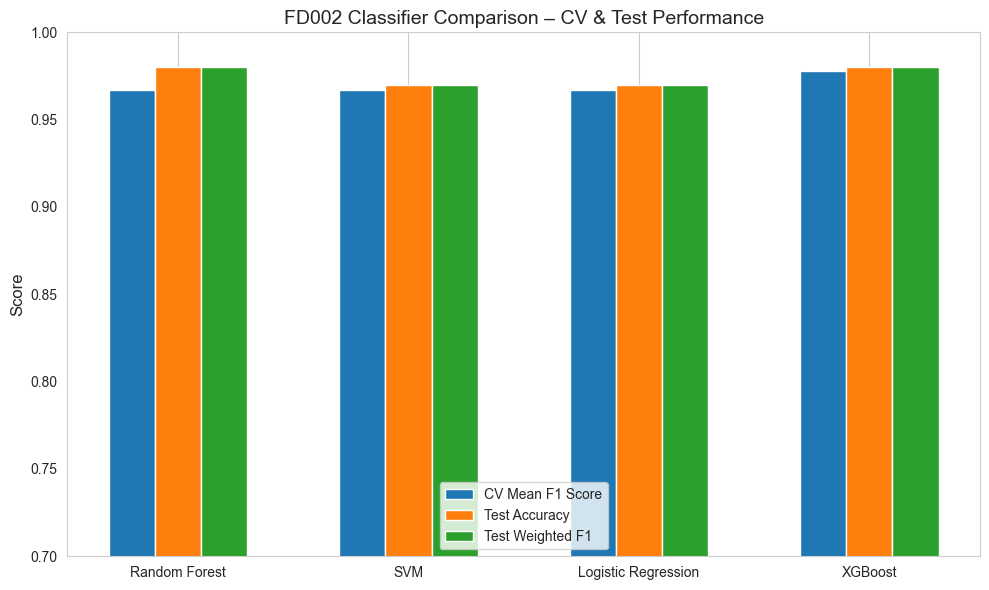

 Comparison plot saved to: c:\Users\pandr\hybrid-predictive-maintenance\figures\phase3\fd002_model_comparison_barplot.png


In [10]:
# Final Step 8: Compare All Classifiers for FD002

import os
import pandas as pd
import matplotlib.pyplot as plt

# Paths
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
FIGURES_DIR = os.path.join(BASE_DIR, 'figures', 'phase3')
REPORT_DIR = os.path.join(BASE_DIR, 'report')
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(REPORT_DIR, exist_ok=True)

# Finalized and validated results
model_comparison_fd002 = {
    'Model': ['Random Forest', 'SVM', 'Logistic Regression', 'XGBoost'],
    'CV Mean F1 Score': [0.9667, 0.9671, 0.9671, 0.9776],
    'Test Accuracy': [0.98, 0.97, 0.97, 0.98],
    'Test Weighted F1': [0.98, 0.97, 0.97, 0.98]
}

# Create DataFrame
df_comparison = pd.DataFrame(model_comparison_fd002)

# Save CSV
comparison_csv_path = os.path.join(REPORT_DIR, 'model_comparison_fd002.csv')
df_comparison.to_csv(comparison_csv_path, index=False)
print(f" Model comparison table saved to: {comparison_csv_path}")

# Plot bar chart
fig, ax = plt.subplots(figsize=(10, 6))
bar_width = 0.2
x = range(len(df_comparison))

for i, metric in enumerate(['CV Mean F1 Score', 'Test Accuracy', 'Test Weighted F1']):
    ax.bar(
        [p + bar_width * i for p in x],
        df_comparison[metric],
        width=bar_width,
        label=metric
    )

# Formatting
ax.set_xticks([p + bar_width for p in x])
ax.set_xticklabels(df_comparison['Model'])
ax.set_ylim(0.7, 1.0)
ax.set_ylabel('Score')
ax.set_title('FD002 Classifier Comparison – CV & Test Performance')
ax.legend()
ax.grid(axis='y')

# Save plot
comparison_plot_path = os.path.join(FIGURES_DIR, 'fd002_model_comparison_barplot.png')
plt.tight_layout()
plt.savefig(comparison_plot_path)
plt.show()

print(f" Comparison plot saved to: {comparison_plot_path}")
